In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

plt.rcParams.update({'text.usetex': True, 'font.size': 13})

# --- Global constants ---
C   = 48.3e-12       # 600 pF
k_b = 1.380649e-23  # J/K
T   = 297.7         # K  (20°C)

# --- Load CSV ---
raw = pd.read_csv('calibration_20.csv', header=None, skiprows=2,
                  names=['freq', 'V_i', 'dV_i', 'V_f', 'dV_f'])
raw['freq'] = pd.to_numeric(raw['freq'], errors='coerce')
for col in ['V_i', 'dV_i', 'V_f', 'dV_f']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# Drop rows where final is missing (can't compute gain)
df = raw.dropna(subset=['V_f', 'dV_f']).copy()
df = df.set_index('freq').sort_index()

# --- Interpolate missing initial values (linear in frequency) ---
df['V_i']  = df['V_i'].interpolate(method='index')
df['dV_i'] = df['dV_i'].interpolate(method='index')

# --- Gain G = (V_f/V_i)^2 and propagated uncertainty ---
gain      = df['V_f'] / df['V_i']
dgain     = gain * np.sqrt((df['dV_f'] / df['V_f'])**2 +
                            (df['dV_i'] / df['V_i'])**2)
df['G']   = gain**2
df['dG']  = 2 * gain * dgain

print(df[['V_i', 'dV_i', 'V_f', 'dV_f', 'G', 'dG']].to_string())


            V_i     dV_i      V_f   dV_f              G            dG
freq                                                                 
10      1.02280  0.00100    1.058  0.005       1.070015      0.010328
100     1.02640  0.00100    1.067  0.005       1.080676      0.010345
200     1.02680  0.00200    1.929  0.005       3.529334      0.022886
300     1.02300  0.00100    8.119  0.005      62.987419      0.145543
400     1.02610  0.00200   25.265  0.005     606.260439      2.375509
500     1.02630  0.00100   61.155  0.005    3550.710654      6.943757
600     1.02760  0.00100  125.270  0.005   14860.929150     28.947886
700     1.02640  0.00100  226.320  0.010   48619.734413     94.835754
800     1.02630  0.00050  366.710  0.010  127672.348863    124.595335
900     1.02580  0.00100  532.700  0.010  269674.575709    525.881402
1000    1.02580  0.00100  692.770  0.050  456092.316100    891.675976
2000    1.02600  0.00100  998.280  0.020  946694.859957   1845.798906
3000    1.02560  0.0

Quantity                                    Value    Uncertainty   Units
------------------------------------------------------------------------------
Area under G                         4.6945e+10   2.0684e+07   Hz
Area under G/(1+2πRCf)²              4.5922e+09   4.2214e+06   Hz
V_rms (Johnson noise)                6.1441e-03   2.8240e-06   V


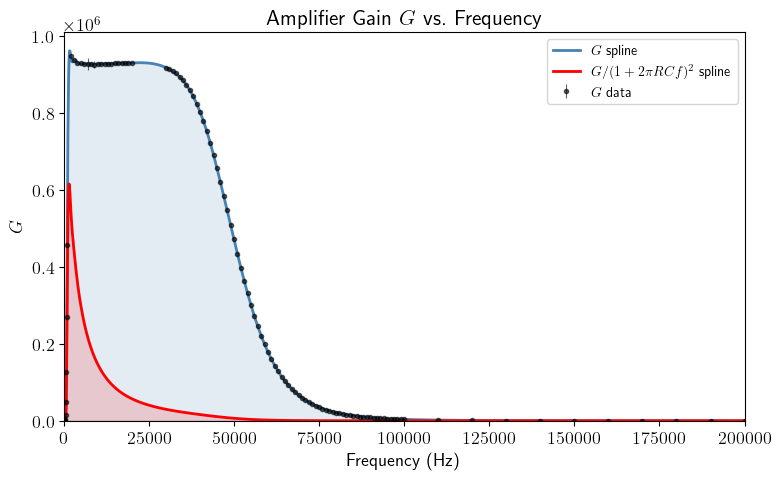

In [3]:
# --- Restrict to freq <= 200000 Hz ---
mask = df.index <= 200_000
freq = df.index[mask].to_numpy(dtype=float)
G    = df['G'][mask].to_numpy()
dG   = df['dG'][mask].to_numpy()

# --- Spline fit to G (R-independent, fit once) ---
spl    = UnivariateSpline(freq, G, w=1.0 / dG, s=len(freq))
f_fine = np.linspace(freq[0], freq[-1], 2000)

# --- General function: RC-corrected G integral as a function of R ---
def compute_G_integral(R, spl, freq, dG, C=C, n_fine=2000):
    """
    Returns (area, uncertainty) of the RC-corrected gain integral.

    Parameters
    ----------
    R     : resistance in Ohms
    spl   : UnivariateSpline fitted to G vs freq
    freq  : frequency array (Hz) used for uncertainty estimate
    dG    : uncertainty on G at each freq point
    C     : capacitance in Farads (default: global C)
    n_fine: number of points for numerical integration
    """
    f          = np.linspace(freq[0], freq[-1], n_fine)
    denom_fine = (1 + 2 * np.pi * R * C * f)**2
    G_rc       = spl(f) / denom_fine

    area = np.trapezoid(G_rc, f)

    steps      = np.diff(freq)
    steps      = np.append(steps, steps[-1])
    denom_data = (1 + 2 * np.pi * R * C * freq)**2
    unc        = np.sqrt(np.sum((dG / denom_data * steps)**2))

    return area, unc

# --- Test case: R = 500 kΩ ---
R_test = 500e3

area_G     = spl.integral(freq[0], freq[-1])
area_G_unc = np.sqrt(np.sum((dG * np.append(np.diff(freq), np.diff(freq)[-1]))**2))

area_rc, area_rc_unc = compute_G_integral(R_test, spl, freq, dG)

V_rms     = np.sqrt(4 * R_test * k_b * T * area_rc)
V_rms_unc = 0.5 * V_rms * area_rc_unc / area_rc

print(f"{'Quantity':<35s}  {'Value':>12s}   {'Uncertainty':>12s}   Units")
print("-" * 78)
print(f"{'Area under G':<35s}  {area_G:.4e}   {area_G_unc:.4e}   Hz")
print(f"{'Area under G/(1+2πRCf)²':<35s}  {area_rc:.4e}   {area_rc_unc:.4e}   Hz")
print(f"{'V_rms (Johnson noise)':<35s}  {V_rms:.4e}   {V_rms_unc:.4e}   V")

# --- Plot ---
denom_fine = (1 + 2 * np.pi * R_test * C * f_fine)**2
G_rc_spl   = spl(f_fine) / denom_fine

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(freq, G, yerr=dG,
            fmt='o', ms=3, lw=0.8, color='black', ecolor='black',
            alpha=0.6, label=r'$G$ data')
ax.fill_between(f_fine, 0, spl(f_fine), alpha=0.15, color='steelblue')
ax.plot(f_fine, spl(f_fine), color='steelblue', lw=2, label=r'$G$ spline')

ax.fill_between(f_fine, 0, G_rc_spl, alpha=0.15, color='red')
ax.plot(f_fine, G_rc_spl, color='red', lw=2,
        label=r'$G/(1+2\pi RCf)^2$ spline')

ax.set_xlabel(r'Frequency (Hz)')
ax.set_ylabel(r'$G$')
ax.set_title(r'Amplifier Gain $G$ vs.~Frequency')
ax.legend(fontsize=10)
ax.set_xlim(left=0, right=200_000)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


In [4]:
# --- Load Johnson noise measurements ---
jn = pd.read_csv('johnson_new_data.csv',
                 usecols=range(6),
                 names=['R', 'dR', 'V_meas', 'dV_meas', 'V_short', 'dV_short'],
                 skiprows=1)

# Convert to SI
R_vals   = jn['R'].to_numpy()      * 1e3   # kΩ → Ω
dR_vals  = jn['dR'].to_numpy()     * 1e3
V_meas   = jn['V_meas'].to_numpy() * 1e-3  # mV → V
dV_meas  = jn['dV_meas'].to_numpy()* 1e-3
V_short  = jn['V_short'].to_numpy()* 1e-3
dV_short = jn['dV_short'].to_numpy()*1e-3

# --- Background subtraction in quadrature ---
# V_johnson² = V_measured² - V_shorted²
Vj2  = V_meas**2 - V_short**2
dVj2 = np.sqrt((2 * V_meas  * dV_meas )**2 +
               (2 * V_short * dV_short)**2)   # σ(V_j²)

# --- Estimate k_b for each measurement ---
# k_b = V_j² / (4 * T * R * G(R))
k_b_vals = []
k_b_uncs = []

for i, R in enumerate(R_vals):
    G_int, dG_int = compute_G_integral(R, spl, freq, dG, C=C)

    k_b_i   = Vj2[i] / (4 * T * R * G_int)

    # Propagate: σ_k/k = sqrt( (σ_Vj²/Vj²)² + (σ_R/R)² + (σ_G/G)² )
    rel_unc = np.sqrt((dVj2[i]  / Vj2[i]  )**2 +
                      (dR_vals[i]/ R       )**2 +
                      (dG_int   / G_int    )**2)
    k_b_i_unc = k_b_i * rel_unc

    k_b_vals.append(k_b_i)
    k_b_uncs.append(k_b_i_unc)

k_b_vals = np.array(k_b_vals)
k_b_uncs = np.array(k_b_uncs)

# --- Combine via inverse-variance weighting ---
weights    = 1 / k_b_uncs**2
k_b_comb   = np.sum(weights * k_b_vals) / np.sum(weights)
k_b_comb_unc = np.sqrt(1 / np.sum(weights))

k_b_true   = 1.380649e-23

print(f"{'Measurement':<14s}  {'R (Ω)':>10s}  {'G(R)':>10s}  {'k_b (J/K)':>12s}  {'Uncertainty':>12s}")
print("-" * 66)
for i, R in enumerate(R_vals):
    G_int, _ = compute_G_integral(R, spl, freq, dG, C=C)
    print(f"{'Meas '+str(i+1):<14s}  {R:>10.1f}  {G_int:>10.4e}  {k_b_vals[i]:>12.4e}  {k_b_uncs[i]:>12.4e}")
print("-" * 66)
print(f"{'Combined':<14s}  {'':>10s}  {'':>10s}  {k_b_comb:>12.4e}  {k_b_comb_unc:>12.4e}")
print(f"{'True value':<14s}  {'':>10s}  {'':>10s}  {k_b_true:>12.4e}")
print(f"\nDiscrepancy: {abs(k_b_comb - k_b_true) / k_b_comb_unc:.2f} σ")

Measurement          R (Ω)        G(R)     k_b (J/K)   Uncertainty
------------------------------------------------------------------
Meas 1            477700.0  4.8086e+09    1.4919e-23    7.1323e-25
Meas 2           1008000.0  2.1360e+09    1.3951e-23    7.1424e-25
Meas 3            816000.0  2.7217e+09    1.4271e-23    2.3738e-25
Meas 4           1006000.0  2.1410e+09    1.3983e-23    4.7613e-25
Meas 5           1008000.0  2.1360e+09    1.3970e-23    4.7629e-25
Meas 6           1008000.0  2.1360e+09    1.4459e-23    4.8411e-25
Meas 7           1008000.0  2.1360e+09    1.4459e-23    4.8411e-25
Meas 8            816000.0  2.7217e+09    1.4721e-23    4.8083e-25
Meas 9            816000.0  2.7217e+09    1.4948e-23    7.2642e-25
Meas 10           816000.0  2.7217e+09    1.4962e-23    4.8463e-25
Meas 11           477000.0  4.8157e+09    1.5658e-23    4.8761e-25
Meas 12           178300.0  1.1630e+10    1.6815e-23    5.3086e-25
Meas 13           334000.0  6.7943e+09    1.6101e-23    4.9850

ODR fit:   k_b = 1.4599e-23 ± 2.5808e-25 J/K
True:      k_b = 1.3806e-23 J/K
Discrepancy: 3.07 σ


/tmp/ipykernel_8416/479731830.py:1: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import ODR, Model, RealData


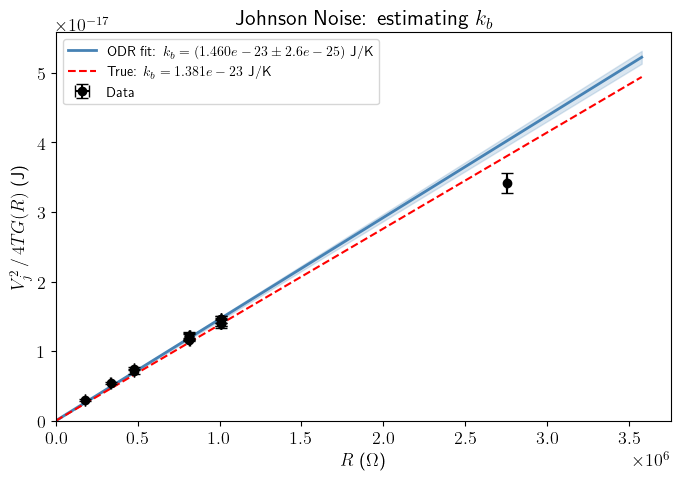

In [5]:
from scipy.odr import ODR, Model, RealData

# --- y = V_j² / (4 T G(R)),  so y = k_b * R ---
y_vals = []
y_uncs = []

for i, R in enumerate(R_vals):
    G_int, dG_int = compute_G_integral(R, spl, freq, dG, C=C)
    y_i   = Vj2[i] / (4 * T * G_int)
    # σ_y/y = sqrt( (σ_Vj²/Vj²)² + (σ_G/G)² )
    y_unc = y_i * np.sqrt((dVj2[i] / Vj2[i])**2 + (dG_int / G_int)**2)
    y_vals.append(y_i)
    y_uncs.append(y_unc)

y_vals = np.array(y_vals)
y_uncs = np.array(y_uncs)

# --- ODR fit: y = k_b * R (through origin) ---
def linear_origin(beta, x):
    return beta[0] * x

odr_data  = RealData(R_vals, y_vals, sx=dR_vals, sy=y_uncs)
odr_model = Model(linear_origin)
odr_fit   = ODR(odr_data, odr_model, beta0=[1.4e-23]).run()

k_b_odr     = odr_fit.beta[0]
k_b_odr_unc = odr_fit.sd_beta[0]

print(f"ODR fit:   k_b = {k_b_odr:.4e} ± {k_b_odr_unc:.4e} J/K")
print(f"True:      k_b = {k_b_true:.4e} J/K")
print(f"Discrepancy: {abs(k_b_odr - k_b_true) / k_b_odr_unc:.2f} σ")

# --- Plot ---
R_line = np.linspace(0, R_vals.max() * 1.3, 300)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(R_vals, y_vals, yerr=y_uncs, xerr=dR_vals,
            fmt='o', ms=6, color='black', ecolor='black', capsize=4,
            label='Data', zorder=3)

ax.plot(R_line, k_b_odr * R_line, color='steelblue', lw=2,
        label=rf'ODR fit: $k_b = ({k_b_odr:.3e} \pm {k_b_odr_unc:.1e})$ J/K')
ax.fill_between(R_line,
                (k_b_odr - k_b_odr_unc) * R_line,
                (k_b_odr + k_b_odr_unc) * R_line,
                alpha=0.2, color='steelblue')

ax.plot(R_line, k_b_true * R_line, color='red', lw=1.5, ls='--',
        label=rf'True: $k_b = {k_b_true:.3e}$ J/K')

ax.set_xlabel(r'$R$ ($\Omega$)')
ax.set_ylabel(r'$V_j^2 \,/\, 4TG(R)$ (J)')
ax.set_title(r'Johnson Noise: estimating $k_b$')
ax.legend(fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


In [ ]:
# --- Temperature-variation analysis (R fixed at 334 kΩ) ---
# At fixed R, V_j² = 4 k_b T R G(R)  =>  V_j² / (4 R G(R)) = k_b * T
# ODR fit slope = k_b

R_fixed = 334e3    # Ω

# --- Load data (same format as johnson_new_data.csv) ---
jn_T = pd.read_csv('johnson_temp_data.csv',
                   usecols=range(7),
                   names=['R', 'dR', 'V_meas', 'dV_meas', 'V_short', 'dV_short', 'T_C'],
                   skiprows=1)

# T column: numeric °C → K (drop "Room" rows)
jn_T['T_C'] = pd.to_numeric(jn_T['T_C'], errors='coerce')
jn_T = jn_T.dropna(subset=['T_C']).reset_index(drop=True)

if jn_T.empty:
    print("No temperature-variation data yet — add rows with numeric T (°C) to johnson_temp_data.csv.")
else:
    T_vals    = jn_T['T_C'].to_numpy() + 273.15          # °C → K
    V_meas_T  = jn_T['V_meas'].to_numpy()  * 1e-3
    dV_meas_T = jn_T['dV_meas'].to_numpy() * 1e-3
    V_short_T = jn_T['V_short'].to_numpy() * 1e-3
    dV_sht_T  = jn_T['dV_short'].to_numpy()* 1e-3

    # Background subtraction
    Vj2_T  = V_meas_T**2 - V_short_T**2
    dVj2_T = np.sqrt((2 * V_meas_T  * dV_meas_T)**2 +
                     (2 * V_short_T * dV_sht_T )**2)

    # G(R_fixed) — computed once
    G_fixed, dG_fixed = compute_G_integral(R_fixed, spl, freq, dG, C=C)

    # y = V_j² / (4 R G(R))  should equal k_b * T
    y_T  = Vj2_T / (4 * R_fixed * G_fixed)
    dy_T = y_T * np.sqrt((dVj2_T / Vj2_T)**2 + (dG_fixed / G_fixed)**2)

    # --- ODR fit: y = k_b * T (through origin) ---
    odr_data_T  = RealData(T_vals, y_T, sy=dy_T)
    odr_model_T = Model(linear_origin)
    odr_fit_T   = ODR(odr_data_T, odr_model_T, beta0=[1.4e-23]).run()

    k_b_T     = odr_fit_T.beta[0]
    k_b_T_unc = odr_fit_T.sd_beta[0]

    print(f"ODR fit:   k_b = {k_b_T:.4e} ± {k_b_T_unc:.4e} J/K")
    print(f"True:      k_b = {k_b_true:.4e} J/K")
    print(f"Discrepancy: {abs(k_b_T - k_b_true) / k_b_T_unc:.2f} σ")

    # --- Plot ---
    T_line = np.linspace(0, T_vals.max() * 1.2, 300)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.errorbar(T_vals, y_T, yerr=dy_T,
                fmt='o', ms=6, color='black', ecolor='black', capsize=4,
                label='Data', zorder=3)
    ax.plot(T_line, k_b_T * T_line, color='steelblue', lw=2,
            label=rf'ODR fit: $k_b = ({k_b_T:.3e} \pm {k_b_T_unc:.1e})$ J/K')
    ax.fill_between(T_line,
                    (k_b_T - k_b_T_unc) * T_line,
                    (k_b_T + k_b_T_unc) * T_line,
                    alpha=0.2, color='steelblue')
    ax.plot(T_line, k_b_true * T_line, color='red', lw=1.5, ls='--',
            label=rf'True: $k_b = {k_b_true:.3e}$ J/K')

    ax.set_xlabel(r'$T$ (K)')
    ax.set_ylabel(r'$V_j^2 \,/\, 4RG(R)$ (J)')
    ax.set_title(rf'Johnson Noise vs.\ Temperature ($R = {R_fixed/1e3:.0f}\ \mathrm{{k\Omega}}$)')
    ax.legend(fontsize=10)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()